# **Case Study: Topological Analysis of Classic Mathematical Spaces**

This notebook explores how our custom topological data analysis library computes Betti numbers and persistence diagrams on classic geometric objects: a solid 2D disk, a 1D circle boundary, a hollow tetrahedron (a 2-sphere equivalent), and a 2D torus. We build these spaces using simplicial complexes, verify their boundary properties, and analyze their topology.

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

from core.topology import Simplex, SimplicialComplex
from core.persistence import Filtration, PersistenceDiagram

## **The Solid Disk ($B^2$)**

A solid disk is a 2D filled space. Mathematically, it is contractible, meaning it can be continuously shrunk to a single point. As a result, we expect it to have:
- One connected component ($H_0$ Betti number $\beta_0 = 1$)
- No 1D loops or holes ($H_1$ Betti number $\beta_1 = 0$)

We represent the disk using a single 2-simplex (a triangle containing 3 vertices, 3 edges, and 1 face).

In [12]:
disk_simplex = Simplex([0,1,2])
disk_sc = SimplicialComplex()
disk_sc.add_simplex(disk_simplex)

print("Allowed:", disk_sc.is_valid())
print(disk_sc.simplices)
print("Dimension:", disk_sc.dim())
print()
print("Is boundary matrix well-defined:", disk_sc.verify_boundary_property())
print("C(2) -> C(1) given by:")
print(disk_sc.boundary_matrix(2))
print()
print("Betti #0:", disk_sc.betti_number(0))
print("Betti #1:", disk_sc.betti_number(1))

Allowed: True
{(0, 1), (2,), (1, 2), (0, 1, 2), (1,), (0, 2), (0,)}
Dimension: 2

Is boundary matrix well-defined: True
C(2) -> C(1) given by:
[[1]
 [1]
 [1]]

Betti #0: 1
Betti #1: 0


### **Simplicial Filtration**

We filter the disk by adding simplices step-by-step based on their dimension (vertices first at $t=0.0$, then edges at $t=1.0$, and finally the solid face at $t=2.0$).

In [13]:
F_disk = Filtration()

for simplex in disk_sc.simplices:
    F_disk.add(simplex, float(simplex.dim()))

print("Growth of a complex:")
for t in F_disk.filtration_values():
    K = F_disk.get_complex(t)
    print(K)

Growth of a complex:
{(0,), (1,), (2,)}
{(0, 1), (1, 2), (2,), (1,), (0, 2), (0,)}
{(0, 1), (1, 2), (2,), (0, 1, 2), (1,), (0, 2), (0,)}


### **Persistent Homology**

Running persistent homology on this filtration shows when each feature is born and dies. The two edges that form the boundary of the disk are born at $t=1.0$ and die at $t=2.0$ when the solid face fills the disk.

[(0, 0.0, inf), (0, 0.0, 1.0), (0, 0.0, 1.0), (1, 1.0, 2.0)]


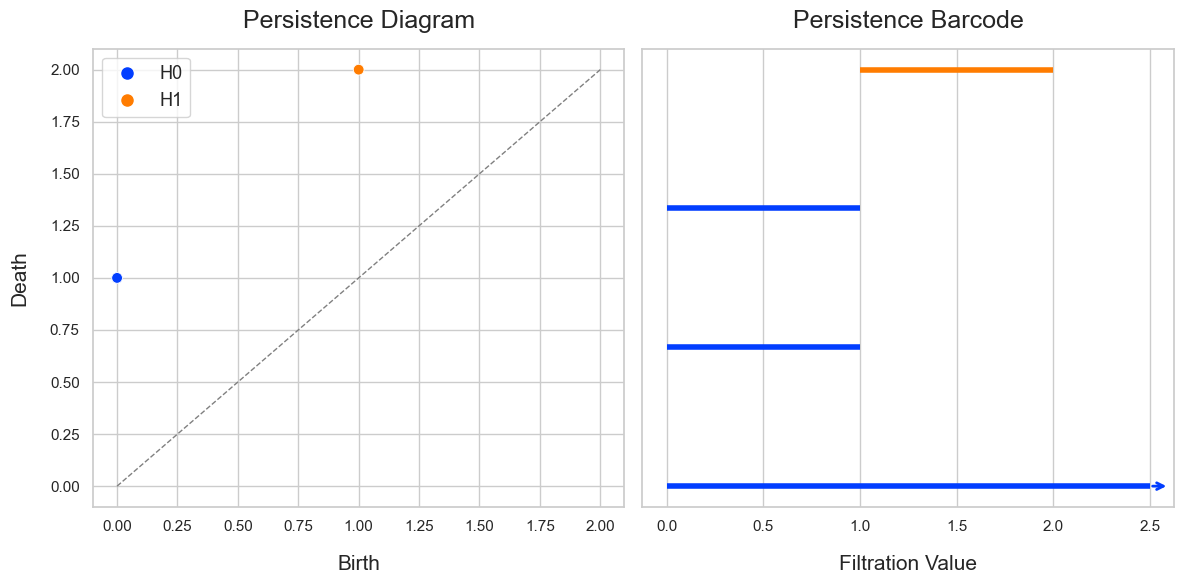

In [14]:
pairs_disk = F_disk.extract_pairs()
print(pairs_disk)

PD_disk = PersistenceDiagram()
for pair in pairs_disk:
    PD_disk.add_pair(pair)

PD_disk.plot_diagram()

## **The Circle ($S^1$)**

Unlike the solid disk, the circle is a hollow 1D loop. It cannot be shrunk to a point without tearing. We expect:
- One connected component ($\beta_0 = 1$)
- One 1D loop ($\beta_1 = 1$)

We build the circle by adding three vertices and three edges connecting them, but omitting the solid 2D face.

In [15]:
circle_simplex_1 = Simplex([0,1])
circle_simplex_2 = Simplex([0,2])
circle_simplex_3 = Simplex([1,2])
circle_list = [circle_simplex_1, circle_simplex_2, circle_simplex_3]

circle_sc = SimplicialComplex()
circle_sc.add_simplices(circle_list)

print("Allowed:", circle_sc.is_valid())
print(circle_sc.simplices)
print("Dimension:", circle_sc.dim())
print()
print("Is boundary matrix well-defined:", circle_sc.verify_boundary_property())
print()
print("Betti #0:", circle_sc.betti_number(0))
print("Betti #1:", circle_sc.betti_number(1))

Allowed: True
{(0, 1), (2,), (1, 2), (1,), (0, 2), (0,)}
Dimension: 1

Is boundary matrix well-defined: True

Betti #0: 1
Betti #1: 1


### **Persistent Homology**

Since the loop is never filled by a 2D face, the 1D loop feature born at $t=1.0$ has an infinite lifetime.

[(0, 0.0, inf), (0, 0.0, 1.0), (0, 0.0, 1.0), (1, 1.0, inf)]


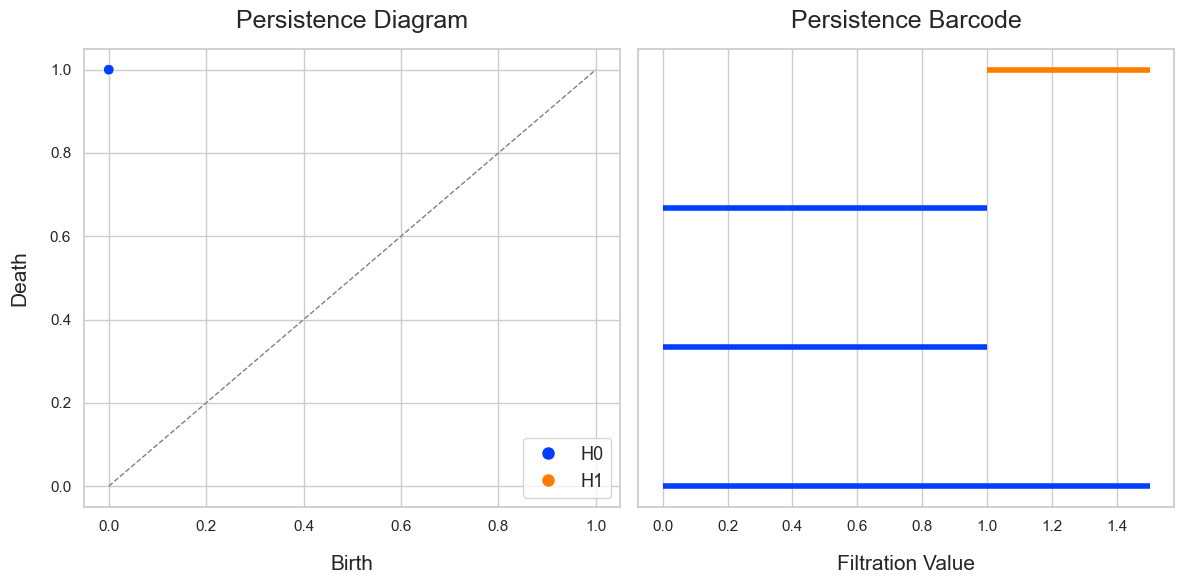

In [16]:
F_circle = Filtration()

for simplex in circle_sc.simplices:
    F_circle.add(simplex, float(simplex.dim()))

pairs_circle = F_circle.extract_pairs()
print(pairs_circle)

PD_circle = PersistenceDiagram()
for pair in pairs_circle:
    PD_circle.add_pair(pair)

PD_circle.plot_diagram()

## **The 2-Sphere $S^2$**

The 2-Sphere is topologically equivalent to the boundary of a tetrahedron and consists of four triangles forming a hollow shell. We expect:
- One connected component ($\beta_0 = 1$)
- No 1D loops, as any loop on the sphere can be shrunk to a point ($\beta_1 = 0$)
- One hollow 2D cavity ($\beta_2 = 1$)

We construct the tetrahedron boundary by adding four 2-simplices (triangles) and all their faces, but omitting the solid 3D interior.

In [17]:
sphere_simplex_1 = Simplex([0,1,2])
sphere_simplex_2 = Simplex([0,1,3])
sphere_simplex_3 = Simplex([0,2,3])
sphere_simplex_4 = Simplex([1,2,3])
sphere_list = [sphere_simplex_1, sphere_simplex_2, sphere_simplex_3, sphere_simplex_4]

sphere_sc = SimplicialComplex()
sphere_sc.add_simplices(sphere_list)

print("Allowed:", sphere_sc.is_valid())
print(sphere_sc.simplices)
print("Dimension:", sphere_sc.dim())
print()
print("Is boundary matrix well-defined:", sphere_sc.verify_boundary_property())
print("C(2) -> C(1) given by:")
print(sphere_sc.boundary_matrix(2))
print()
print("Betti #0:", sphere_sc.betti_number(0))
print("Betti #1:", sphere_sc.betti_number(1))
print("Betti #2:", sphere_sc.betti_number(2))


Allowed: True
{(0, 1), (1, 3), (2,), (1, 2), (0, 1, 2), (0, 1, 3), (0, 3), (0, 2, 3), (1, 2, 3), (2, 3), (1,), (0, 2), (0,), (3,)}
Dimension: 2

Is boundary matrix well-defined: True
C(2) -> C(1) given by:
[[1 1 0 0]
 [1 0 1 0]
 [0 1 1 0]
 [1 0 0 1]
 [0 1 0 1]
 [0 0 1 1]]

Betti #0: 1
Betti #1: 0
Betti #2: 1


### **Persistent Homology**

Running persistent homology on the 2-Sphere boundary filtration reveals the birth and death of its topological features:
- $H_0$ features (vertices) are born at $t=0.0$.
- $H_1$ features (1D loops) are born at $t=1.0$ when the edges are added, and die at $t=2.0$ when the triangles fill them.
- The $H_2$ feature (the hollow cavity) is born at $t=2.0$ when the final triangle completes the boundary shell, and has an infinite lifetime.

[(0, 0.0, inf), (0, 0.0, 1.0), (0, 0.0, 1.0), (0, 0.0, 1.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (2, 2.0, inf)]


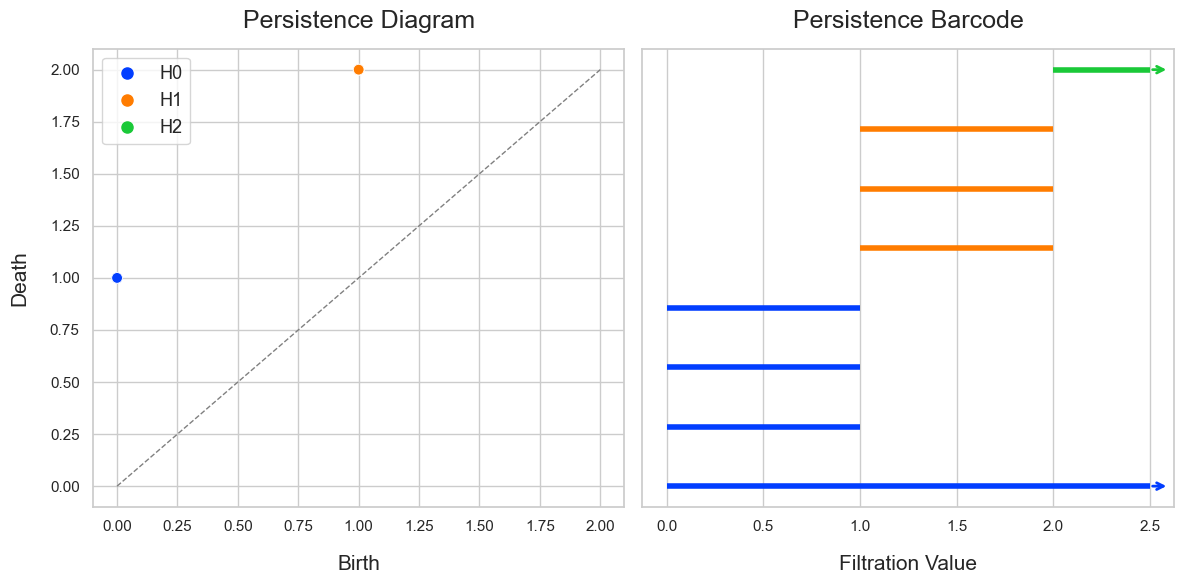

In [18]:
F_sphere = Filtration()

for simplex in sphere_sc.simplices:
    F_sphere.add(simplex, float(simplex.dim()))

pairs_sphere = F_sphere.extract_pairs()
print(pairs_sphere)

PD_sphere = PersistenceDiagram()
for pair in pairs_sphere:
    PD_sphere.add_pair(pair)

PD_sphere.plot_diagram()

## **The Torus ($T^2$)**

A torus is a donut-shaped surface. It has a richer topological structure. We expect:
- One connected component ($\beta_0 = 1$)
- Two independent 1D loops: one going around the tube, and one going through the central hole ($\beta_1 = 2$)
- One hollow 2D cavity inside the surface ($\beta_2 = 1$)

We represent the torus using a triangulation consisting of 7 vertices, 21 edges, and 14 triangles.

In [19]:
t0 = Simplex([0, 1, 3])
t1 = Simplex([1, 2, 4])
t2 = Simplex([2, 3, 5])
t3 = Simplex([3, 4, 6])
t4 = Simplex([0, 4, 5])
t5 = Simplex([1, 5, 6])
t6 = Simplex([0, 2, 6])

t7 = Simplex([0, 1, 5])
t8 = Simplex([1, 2, 6])
t9 = Simplex([0, 2, 3])
t10 = Simplex([1, 3, 4])
t11 = Simplex([2, 4, 5])
t12 = Simplex([3, 5, 6])
t13 = Simplex([0, 4, 6])

torus_list = [
    t0, t1, t2,
    t3, t4, t5, t6,
    t7, t8, t9, t10,
    t11, t12, t13
]

torus_sc = SimplicialComplex()
torus_sc.add_simplices(torus_list)

print("Allowed:", torus_sc.is_valid())
print("Dimension:", torus_sc.dim())
print("Is boundary matrix well-defined:", torus_sc.verify_boundary_property())
print()
print("Betti #0:", torus_sc.betti_number(0))
print("Betti #1:", torus_sc.betti_number(1))
print("Betti #2:", torus_sc.betti_number(2))

Allowed: True
Dimension: 2
Is boundary matrix well-defined: True

Betti #0: 1
Betti #1: 2
Betti #2: 1


### **Persistent Homology**

We filter the torus triangulation using simplex dimensions:
- Vertices ($H_0$) are born at $t=0.0$.
- 1D loops ($H_1$, including the two main generators of the torus) are born at $t=1.0$ and die at $t=2.0$ when the triangles fill them.
- The 2D hollow cavity ($H_2$) is born at $t=2.0$ when the final triangles are added to close the surface, and has an infinite lifetime.

[(0, 0.0, inf), (0, 0.0, 1.0), (0, 0.0, 1.0), (0, 0.0, 1.0), (0, 0.0, 1.0), (0, 0.0, 1.0), (0, 0.0, 1.0), (1, 1.0, inf), (1, 1.0, 2.0), (1, 1.0, inf), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (1, 1.0, 2.0), (2, 2.0, inf)]


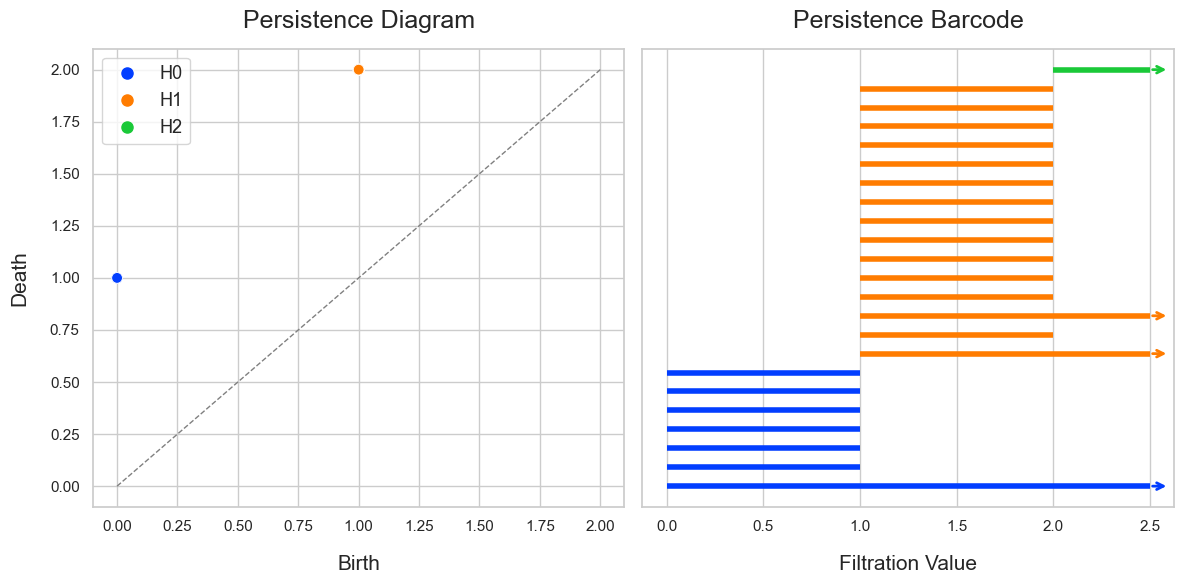

In [20]:
F_torus = Filtration()

for simplex in torus_sc.simplices:
    F_torus.add(simplex, float(simplex.dim()))

pairs_torus = F_torus.extract_pairs()
print(pairs_torus)

PD_torus = PersistenceDiagram()
for pair in pairs_torus:
    PD_torus.add_pair(pair)

PD_torus.plot_diagram()